In [2]:
import xarray as xr
import glob

# Step 1: Load all NetCDF files
files = glob.glob('C:/Users/grace.UOPNET/Desktop/data/*.nc')  # replace YOUR_USERNAME if needed

data = xr.open_mfdataset(files, combine='by_coords', decode_times=True)
data


<xarray.Dataset>
Dimensions:       (time: 2924, latitude: 193, longitude: 195)
Coordinates:
  * time          (time) datetime64[ns] 2014-05-30 2014-05-31 ... 2022-05-31
  * latitude      (latitude) float32 9.475 9.525 9.575 ... 18.98 19.02 19.07
  * longitude     (longitude) float32 84.03 84.08 84.12 ... 93.62 93.68 93.73
Data variables:
    analysed_sst  (time, latitude, longitude) float32 dask.array<chunksize=(216, 193, 195), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.11
    title:             Global SST & Sea Ice Analysis, L4 OSTIA, 0.05 deg dail...
    institution:       UKMO
    source:            AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, GOES<13,16...
    history:           Created from sst.nc; obs_anal.nc; seaice.nc
    references:        Donlon, C.J., Martin, M., Stark, J.D., Roberts-Jones, ...
    comment:           WARNING Some applications are unable to properly handl...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SST_GLO_SST_L4_REP_OBSERVATIONS_010_011
    subset:datasetId:  METOFFICE-GLO-SST-L4-REP-OBS-SST_202003
    subset:date:       2025-06-20T09:36:22.010Z

In [3]:
# Step 2: Select SST variable and convert to Celsius
sst = data['analysed_sst'] - 273.15  # Convert from Kelvin to Celsius
sst.name = 'sst_celsius'  # Rename for clarity

sst


<xarray.DataArray 'sst_celsius' (time: 2924, latitude: 193, longitude: 195)>
dask.array<sub, shape=(2924, 193, 195), dtype=float32, chunksize=(366, 193, 195), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2014-05-30 2014-05-31 ... 2022-05-31
  * latitude   (latitude) float32 9.475 9.525 9.575 9.625 ... 18.98 19.02 19.07
  * longitude  (longitude) float32 84.03 84.08 84.12 84.18 ... 93.62 93.68 93.73

In [4]:
# Step 3: Compute monthly climatology (mean SST per calendar month)
sst_climatology = sst.groupby('time.month').mean(dim='time', skipna=True)
sst_climatology


<xarray.DataArray 'sst_celsius' (month: 12, latitude: 193, longitude: 195)>
dask.array<stack, shape=(12, 193, 195), dtype=float32, chunksize=(1, 193, 195), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 9.475 9.525 9.575 9.625 ... 18.98 19.02 19.07
  * longitude  (longitude) float32 84.03 84.08 84.12 84.18 ... 93.62 93.68 93.73
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [5]:
# Step 4: Compute SST anomaly
sst_anomaly = sst.groupby('time.month') - sst_climatology
sst_anomaly.name = 'sst_anomaly'
sst_anomaly


<xarray.DataArray 'sst_anomaly' (time: 2924, latitude: 193, longitude: 195)>
dask.array<sub, shape=(2924, 193, 195), dtype=float32, chunksize=(31, 193, 195), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2014-05-30 2014-05-31 ... 2022-05-31
  * latitude   (latitude) float32 9.475 9.525 9.575 9.625 ... 18.98 19.02 19.07
  * longitude  (longitude) float32 84.03 84.08 84.12 84.18 ... 93.62 93.68 93.73
    month      (time) int64 5 5 6 6 6 6 6 6 6 6 6 6 ... 5 5 5 5 5 5 5 5 5 5 5 5

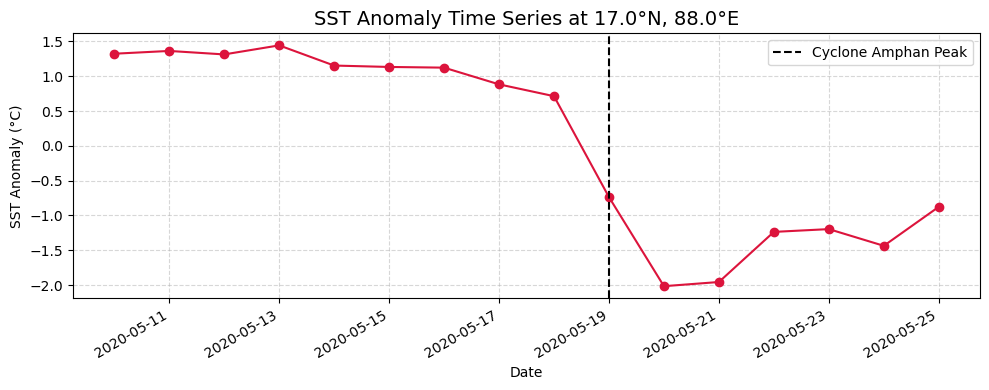

In [8]:
import pandas as pd

# Step 6: Define point location and time window
lat_pt = 17.0
lon_pt = 88.0
time_range = slice('2020-05-10', '2020-05-25')


# Extract anomaly time series at point
sst_anom_point = sst_anomaly.sel(latitude=lat_pt, longitude=lon_pt, method='nearest')
sst_anom_point = sst_anom_point.sel(time=time_range)

# Plot time series
plt.figure(figsize=(10, 4))
sst_anom_point.plot(marker='o', color='crimson')
plt.axvline(pd.Timestamp('2020-05-19'), color='black', linestyle='--', label='Cyclone Amphan Peak')
plt.title(f'SST Anomaly Time Series at {lat_pt}°N, {lon_pt}°E', fontsize=14)
plt.ylabel('SST Anomaly (°C)')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
fig.savefig("sst anomaly graph.png", dpi=300, bbox_inches='tight')
plt.show()


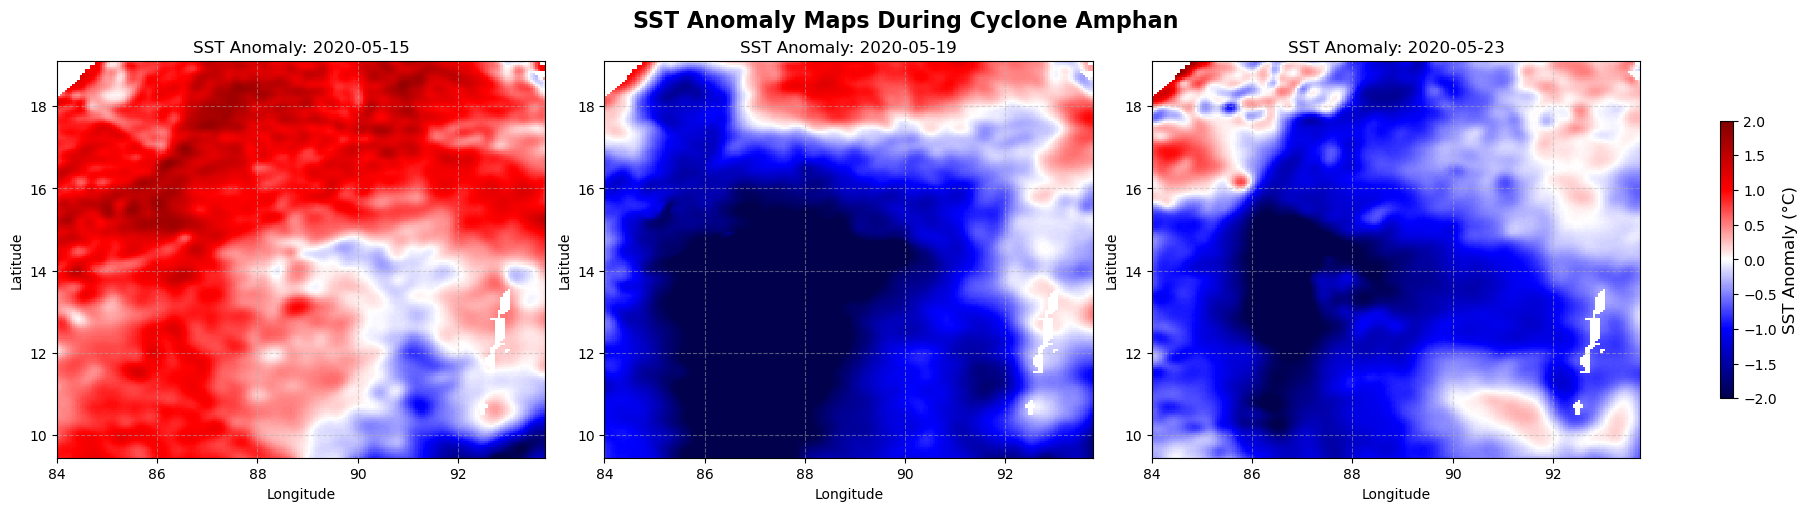

In [9]:
import matplotlib.pyplot as plt

# Step 7: Key dates to compare
dates = ['2020-05-15', '2020-05-19', '2020-05-23']  # before, peak, after

# Create figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for i, date in enumerate(dates):
    ax = axs[i]
    sst_day = sst_anomaly.sel(time=date, method='nearest')
    
    # Dramatic colormap with set range
    im = sst_day.plot(ax=ax,
                      cmap='seismic',
                      vmin=-2, vmax=2,  # Clipping the color scale
                      center=0,
                      add_colorbar=False)
    
    ax.set_title(f"SST Anomaly: {date}", fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle='--', alpha=0.5)

# Shared colorbar
cbar = fig.colorbar(im, ax=axs, orientation='vertical', shrink=0.7)
cbar.set_label('SST Anomaly (°C)', fontsize=12)

# Main title
plt.suptitle("SST Anomaly Maps During Cyclone Amphan", fontsize=16, weight='bold')
fig.savefig("sst anomaly.png", dpi=300, bbox_inches='tight')

plt.show()
